In [1]:
# ============================================================
# CELL 1: Imports + robust geometry loading
# ============================================================

from __future__ import annotations

import os
import math
import time
import json
import random
import warnings
from collections import defaultdict
from typing import Dict, List, Optional, Tuple

import numpy as np

from shapely.geometry import (
    Polygon,
    MultiPolygon,
    LineString,
    MultiLineString,
)
from shapely import wkt as shapely_wkt

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# Helpers for geometry conversion
# ------------------------------------------------------------

def _linestring_to_polygon(geom):
    """
    Convert a LineString that represents a ring into a Polygon.
    Safely handles empty / degenerate line strings.
    """
    if geom is None or geom.is_empty:
        raise ValueError("empty LineString")

    coords = list(geom.coords)

    if len(coords) == 0:
        raise ValueError("LineString has no coordinates")

    # Need at least 3 points before closure
    if len(coords) < 3:
        raise ValueError(f"LineString too short for polygon conversion: {len(coords)} coords")

    if coords[0] != coords[-1]:
        coords.append(coords[0])   # force close the ring

    # Polygon ring needs at least 4 coordinates after closing
    if len(coords) < 4:
        raise ValueError(f"closed ring too short: {len(coords)} coords")

    poly = Polygon(coords)

    if poly.is_empty:
        raise ValueError("converted polygon is empty")

    if not poly.is_valid:
        poly = poly.buffer(0)

    if poly.is_empty:
        raise ValueError("polygon became empty after validity fix")

    return poly


def _geom_to_polygon(geom):
    """
    Convert supported geometry types into Polygon / MultiPolygon.
    """
    if geom is None or geom.is_empty:
        raise ValueError("empty geometry")

    if geom.geom_type in ("Polygon", "MultiPolygon"):
        return geom

    if geom.geom_type == "LineString":
        return _linestring_to_polygon(geom)

    if geom.geom_type == "MultiLineString":
        polys = []
        for ls in geom.geoms:
            try:
                poly = _linestring_to_polygon(ls)
                polys.append(poly)
            except Exception:
                continue

        if not polys:
            raise ValueError("MultiLineString has no valid polygonal parts")

        if len(polys) == 1:
            return polys[0]
        return MultiPolygon(polys)

    raise ValueError(f"Cannot convert {geom.geom_type} to Polygon")


def _parse_tsv_line(line: str):
    """
    Parse one line of format:

        <id> <WKT> [key#value,key#value,...]

    Returns:
        feat_id, wkt_str, tag_dict
    """
    line = line.rstrip("\n").strip()
    if not line:
        raise ValueError("empty line")

    # First whitespace splits ID from the rest
    first_space = -1
    for ci, ch in enumerate(line):
        if ch in (" ", "\t"):
            first_space = ci
            break

    if first_space == -1:
        raise ValueError("no whitespace found — cannot split ID from WKT")

    feat_id = line[:first_space].strip()

    # Tags start from last '[' if present
    tag_start = line.rfind("[")
    if tag_start != -1:
        tag_raw = line[tag_start:].strip().strip("[]")
        rest = line[first_space:tag_start]
    else:
        tag_raw = ""
        rest = line[first_space:]

    wkt_str = rest.strip()
    if not wkt_str:
        raise ValueError("empty WKT field")

    tag_dict = {}
    for item in tag_raw.split(","):
        item = item.strip()
        if "#" in item:
            k, _, v = item.partition("#")
            tag_dict[k.strip()] = v.strip()

    return feat_id, wkt_str, tag_dict


def load_geometries(path: str) -> Tuple[List, List[str], List[dict]]:
    """
    Load geometries, IDs, and tags.

    Supported:
      - .tsv : <id> <WKT> [tags]
      - .wkt / .txt : one WKT per line
      - others via GeoPandas
    """
    geometries = []
    ids = []
    tags = []
    skipped = 0

    if path.endswith(".tsv"):
        with open(path, encoding="utf-8") as fh:
            for lineno, line in enumerate(fh, 1):
                try:
                    feat_id, wkt_str, tag_dict = _parse_tsv_line(line)
                except ValueError as exc:
                    if line.strip():
                        print(f"[skip] line {lineno}: {exc}")
                    skipped += 1
                    continue

                try:
                    geom = shapely_wkt.loads(wkt_str)
                except Exception as exc:
                    print(f"[skip] line {lineno} id={feat_id}: WKT error — {exc}")
                    print(f"       WKT preview: {wkt_str[:200]}")
                    skipped += 1
                    continue

                try:
                    geom = _geom_to_polygon(geom)
                except Exception as exc:
                    print(f"[skip] line {lineno} id={feat_id}: geometry conversion error — {exc}")
                    print(f"       WKT preview: {wkt_str[:200]}")
                    skipped += 1
                    continue

                if not geom.is_valid:
                    geom = geom.buffer(0)

                if geom.is_empty:
                    skipped += 1
                    continue

                geometries.append(geom)
                ids.append(feat_id)
                tags.append(tag_dict)

    elif path.endswith(".wkt") or path.endswith(".txt"):
        with open(path, encoding="utf-8") as fh:
            for lineno, line in enumerate(fh, 1):
                line = line.strip()
                if not line:
                    continue
                try:
                    geom = shapely_wkt.loads(line)
                    geom = _geom_to_polygon(geom)

                    if not geom.is_valid:
                        geom = geom.buffer(0)

                    if geom.is_empty:
                        raise ValueError("empty geometry after fix")

                    geometries.append(geom)
                    ids.append(str(lineno))
                    tags.append({})
                except Exception as exc:
                    print(f"[skip] line {lineno}: {exc}")
                    skipped += 1

    else:
        import geopandas as gpd

        gdf = gpd.read_file(path)
        for i, row in gdf.iterrows():
            geom = row.geometry
            if geom is None or geom.is_empty:
                skipped += 1
                continue

            try:
                geom = _geom_to_polygon(geom)

                if not geom.is_valid:
                    geom = geom.buffer(0)

                if geom.is_empty:
                    raise ValueError("empty geometry after fix")

                geometries.append(geom)
                ids.append(str(i))
                tags.append({})
            except Exception as exc:
                print(f"[skip] row {i}: {exc}")
                skipped += 1

    print(f"Loaded {len(geometries):,} valid geometries ({skipped} skipped) from {path}")
    return geometries, ids, tags


def to_multipolygon(geom) -> MultiPolygon:
    if geom.geom_type == "Polygon":
        return MultiPolygon([geom])
    elif geom.geom_type == "MultiPolygon":
        return geom
    raise ValueError(f"Unsupported geometry type: {geom.geom_type}")


print("Cell 1 loaded successfully.")

Cell 1 loaded successfully.


In [7]:
# ============================================================
# CELL 2: Silent loader + summary only
# ============================================================

from collections import Counter

DATA_PATH = "/raid/ruban/data/parks.tsv"

def load_geometries_silent(path: str):
    geometries = []
    ids = []
    tags = []

    skipped = 0
    skip_reasons = Counter()

    with open(path, encoding="utf-8") as fh:
        for lineno, line in enumerate(fh, 1):
            try:
                feat_id, wkt_str, tag_dict = _parse_tsv_line(line)
            except Exception:
                skipped += 1
                skip_reasons["parse_error"] += 1
                continue

            try:
                geom = shapely_wkt.loads(wkt_str)
            except Exception:
                skipped += 1
                skip_reasons["wkt_parse_error"] += 1
                continue

            try:
                geom = _geom_to_polygon(geom)
            except Exception as exc:
                skipped += 1
                msg = str(exc).lower()

                if "too short" in msg:
                    skip_reasons["degenerate_linestring"] += 1
                elif "empty" in msg:
                    skip_reasons["empty_geometry"] += 1
                elif "closed ring too short" in msg:
                    skip_reasons["short_closed_ring"] += 1
                else:
                    skip_reasons["geometry_conversion_error"] += 1
                continue

            try:
                if not geom.is_valid:
                    geom = geom.buffer(0)
                if geom.is_empty:
                    skipped += 1
                    skip_reasons["empty_after_fix"] += 1
                    continue
            except Exception:
                skipped += 1
                skip_reasons["post_fix_error"] += 1
                continue

            geometries.append(geom)
            ids.append(feat_id)
            tags.append(tag_dict)

    print("=== LOAD SUMMARY ===")
    print(f"Valid geometries : {len(geometries):,}")
    print(f"Skipped          : {skipped:,}")
    print(f"Kept ratio       : {len(geometries) / (len(geometries) + skipped):.4f}")

    print("\n=== SKIP REASONS ===")
    for k, v in skip_reasons.most_common():
        print(f"{k:24s}: {v:,}")

    return geometries, ids, tags, skip_reasons


# Run this
geometries, ids, tags, skip_reasons = load_geometries_silent(DATA_PATH)

print("\n=== GEOMETRY TYPE SUMMARY ===")
type_counts = Counter(g.geom_type for g in geometries)
for k, v in sorted(type_counts.items()):
    print(f"{k:15s}: {v:,}")

=== LOAD SUMMARY ===
Valid geometries : 234,195
Skipped          : 252
Kept ratio       : 0.9989

=== SKIP REASONS ===
degenerate_linestring   : 196
empty_geometry          : 46
wkt_parse_error         : 10

=== GEOMETRY TYPE SUMMARY ===
MultiPolygon   : 114
Polygon        : 234,081


In [8]:
# ============================================================
# CELL 3: Normalize geometry objects + create a debug subset
# ============================================================

import numpy as np
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

def extract_outer_rings(geom):
    """
    Return a list of outer rings.
    Each ring is a numpy array of shape [num_points, 2].
    """
    rings = []

    if geom.geom_type == "Polygon":
        coords = np.asarray(geom.exterior.coords, dtype=np.float32)
        if len(coords) >= 4:
            rings.append(coords)

    elif geom.geom_type == "MultiPolygon":
        for poly in geom.geoms:
            coords = np.asarray(poly.exterior.coords, dtype=np.float32)
            if len(coords) >= 4:
                rings.append(coords)

    return rings


def ring_signed_area(coords):
    """
    Shoelace signed area for a closed ring.
    """
    x = coords[:, 0]
    y = coords[:, 1]
    return 0.5 * np.sum(x[:-1] * y[1:] - x[1:] * y[:-1])


def choose_main_ring(geom):
    """
    Choose the largest outer ring.
    This keeps the first debug version simple: one ring per geometry.
    """
    rings = extract_outer_rings(geom)
    if not rings:
        return None

    best_ring = None
    best_area = -1.0

    for ring in rings:
        area = abs(ring_signed_area(ring))
        if area > best_area:
            best_area = area
            best_ring = ring

    return best_ring


# Build normalized ring list
main_rings = []
main_ids = []

for geom, feat_id in zip(geometries, ids):
    ring = choose_main_ring(geom)
    if ring is None:
        continue
    main_rings.append(ring)
    main_ids.append(feat_id)

print("=== NORMALIZED DATASET ===")
print(f"Usable geometries with main ring : {len(main_rings):,}")

vertex_counts = np.array([len(r) for r in main_rings], dtype=np.int32)
print(f"Min vertices   : {vertex_counts.min()}")
print(f"Median vertices: {int(np.median(vertex_counts))}")
print(f"p90 vertices   : {int(np.percentile(vertex_counts, 90))}")
print(f"p99 vertices   : {int(np.percentile(vertex_counts, 99))}")
print(f"Max vertices   : {vertex_counts.max()}")

# Small debug subset first
DEBUG_N = 2000   # keep small for now
debug_idx = np.random.choice(len(main_rings), size=min(DEBUG_N, len(main_rings)), replace=False)

rings_debug = [main_rings[i] for i in debug_idx]
ids_debug = [main_ids[i] for i in debug_idx]

print("\n=== DEBUG SUBSET ===")
print(f"Subset size : {len(rings_debug):,}")

for i in range(min(5, len(rings_debug))):
    r = rings_debug[i]
    print(f"[{i}] id={ids_debug[i]} shape={r.shape} first_point={r[0]}")

=== NORMALIZED DATASET ===
Usable geometries with main ring : 234,195
Min vertices   : 4
Median vertices: 10
p90 vertices   : 31
p99 vertices   : 107
Max vertices   : 1895

=== DEBUG SUBSET ===
Subset size : 2,000
[0] id=178469575 shape=(9, 2) first_point=[-68.02319  -38.950733]
[1] id=174443195 shape=(5, 2) first_point=[-73.72178   45.360004]
[2] id=62067021 shape=(19, 2) first_point=[-5.6317344 40.974724 ]
[3] id=77287317 shape=(5, 2) first_point=[-58.505592 -34.515644]
[4] id=37817061 shape=(9, 2) first_point=[ 8.69476  47.254753]


In [9]:
# ============================================================
# CELL 4: Convert polygon rings into graph samples
# ============================================================

def normalize_ring(coords):
    """
    Normalize a ring to make learning easier.
    Center at origin and scale by max radius.
    """
    coords = np.asarray(coords, dtype=np.float32)

    # Remove duplicated last point if ring is closed
    if len(coords) >= 2 and np.allclose(coords[0], coords[-1]):
        coords = coords[:-1]

    center = coords.mean(axis=0, keepdims=True)
    coords_centered = coords - center

    scale = np.sqrt((coords_centered ** 2).sum(axis=1)).max()
    if scale < 1e-8:
        scale = 1.0

    coords_norm = coords_centered / scale
    return coords_norm.astype(np.float32)


def build_cycle_edge_index(num_nodes):
    """
    Build undirected cycle edges:
    0-1-2-...-(n-1)-0
    returned as shape [2, E]
    """
    src = []
    dst = []

    for i in range(num_nodes):
        j = (i + 1) % num_nodes

        # forward
        src.append(i)
        dst.append(j)

        # backward
        src.append(j)
        dst.append(i)

    edge_index = np.asarray([src, dst], dtype=np.int64)
    return edge_index


def ring_to_graph_sample(ring, feat_id):
    """
    Convert one polygon ring into a graph dict.
    """
    x = normalize_ring(ring)                 # [N, 2]
    edge_index = build_cycle_edge_index(len(x))   # [2, E]

    sample = {
        "id": feat_id,
        "x": x,
        "edge_index": edge_index,
        "num_nodes": x.shape[0],
        "num_edges": edge_index.shape[1],
    }
    return sample


graph_samples_debug = [ring_to_graph_sample(r, fid) for r, fid in zip(rings_debug, ids_debug)]

print("=== GRAPH SAMPLE SUMMARY ===")
print(f"Total graph samples: {len(graph_samples_debug):,}")

num_nodes_arr = np.array([g["num_nodes"] for g in graph_samples_debug], dtype=np.int32)
num_edges_arr = np.array([g["num_edges"] for g in graph_samples_debug], dtype=np.int32)

print(f"Min nodes   : {num_nodes_arr.min()}")
print(f"Median nodes: {int(np.median(num_nodes_arr))}")
print(f"p90 nodes   : {int(np.percentile(num_nodes_arr, 90))}")
print(f"Max nodes   : {num_nodes_arr.max()}")

print(f"Min edges   : {num_edges_arr.min()}")
print(f"Median edges: {int(np.median(num_edges_arr))}")
print(f"Max edges   : {num_edges_arr.max()}")

print("\n=== FIRST SAMPLE ===")
g0 = graph_samples_debug[0]
print("id         :", g0["id"])
print("x shape    :", g0["x"].shape)
print("edge shape :", g0["edge_index"].shape)
print("first nodes:\n", g0["x"][:5])
print("first edges:\n", g0["edge_index"][:, :10])

=== GRAPH SAMPLE SUMMARY ===
Total graph samples: 2,000
Min nodes   : 3
Median nodes: 8
p90 nodes   : 31
Max nodes   : 1732
Min edges   : 6
Median edges: 16
Max edges   : 3464

=== FIRST SAMPLE ===
id         : 178469575
x shape    : (8, 2)
edge shape : (2, 16)
first nodes:
 [[-0.9428742  -0.3331489 ]
 [-0.50286627 -0.6788694 ]
 [-0.27657643 -0.50915205]
 [-0.47772294 -0.27657643]
 [ 0.35200638  0.38972133]]
first edges:
 [[0 1 1 2 2 3 3 4 4 5]
 [1 0 2 1 3 2 4 3 5 4]]


In [11]:
# ============================================================
# CELL 5: Convert graph dicts into PyTorch Geometric Data
# ============================================================

import torch

PYG_AVAILABLE = False
pyg_graphs_debug = []

try:
    from torch_geometric.data import Data
    PYG_AVAILABLE = True
    print("torch_geometric is installed.")
except ImportError:
    print("torch_geometric is NOT installed.")


if PYG_AVAILABLE:
    def graph_dict_to_pyg_data(sample):
        x = torch.tensor(sample["x"], dtype=torch.float32)                 # [N, 2]
        edge_index = torch.tensor(sample["edge_index"], dtype=torch.long) # [2, E]

        data = Data(x=x, edge_index=edge_index)
        data.poly_id = str(sample["id"])
        data.num_nodes_manual = sample["num_nodes"]
        data.num_edges_manual = sample["num_edges"]
        return data

    pyg_graphs_debug = [graph_dict_to_pyg_data(g) for g in graph_samples_debug]

    print("\n=== PYG CONVERSION SUMMARY ===")
    print(f"PyG graphs created: {len(pyg_graphs_debug):,}")

    g0 = pyg_graphs_debug[0]
    print("\n=== FIRST PYG GRAPH ===")
    print(g0)
    print("poly_id      :", g0.poly_id)
    print("x.shape      :", tuple(g0.x.shape))
    print("edge_index   :", tuple(g0.edge_index.shape))
    print("num_nodes    :", g0.num_nodes)
    print("first x rows :\n", g0.x[:5])
    print("first edges  :\n", g0.edge_index[:, :10])

else:
    print("\nPyG conversion skipped because torch_geometric is unavailable.")
    print("Next step will be to install torch_geometric or switch to plain PyTorch graph batching.")

torch_geometric is installed.

=== PYG CONVERSION SUMMARY ===
PyG graphs created: 2,000

=== FIRST PYG GRAPH ===
Data(x=[8, 2], edge_index=[2, 16], poly_id='178469575', num_nodes_manual=8, num_edges_manual=16)
poly_id      : 178469575
x.shape      : (8, 2)
edge_index   : (2, 16)
num_nodes    : 8
first x rows :
 tensor([[-0.9429, -0.3331],
        [-0.5029, -0.6789],
        [-0.2766, -0.5092],
        [-0.4777, -0.2766],
        [ 0.3520,  0.3897]])
first edges  :
 tensor([[0, 1, 1, 2, 2, 3, 3, 4, 4, 5],
        [1, 0, 2, 1, 3, 2, 4, 3, 5, 4]])


In [12]:
# ============================================================
# CELL 6: Graph augmentation + train/val split + triplet dataset
# ============================================================

import copy
import math
import random
import torch
from torch.utils.data import Dataset

# -----------------------------
# Train / validation split
# -----------------------------
num_graphs = len(pyg_graphs_debug)
indices = list(range(num_graphs))
random.shuffle(indices)

train_ratio = 0.9
train_size = int(train_ratio * num_graphs)

train_idx = indices[:train_size]
val_idx = indices[train_size:]

train_graphs = [pyg_graphs_debug[i] for i in train_idx]
val_graphs = [pyg_graphs_debug[i] for i in val_idx]

print("=== SPLIT SUMMARY ===")
print(f"Total graphs : {num_graphs:,}")
print(f"Train graphs : {len(train_graphs):,}")
print(f"Val graphs   : {len(val_graphs):,}")


# -----------------------------
# Geometry augmentation
# -----------------------------
def rotate_points(x, angle_rad):
    c = math.cos(angle_rad)
    s = math.sin(angle_rad)
    R = torch.tensor([[c, -s], [s, c]], dtype=x.dtype, device=x.device)
    return x @ R.T

def jitter_points(x, sigma=0.02):
    noise = torch.randn_like(x) * sigma
    return x + noise

def scale_points(x, scale_min=0.9, scale_max=1.1):
    scale = random.uniform(scale_min, scale_max)
    return x * scale

def maybe_reverse_cycle(data):
    """
    Reverse node order sometimes.
    Rebuild cycle edges afterward.
    """
    if random.random() > 0.5:
        return data

    x = data.x.flip(0)
    n = x.shape[0]

    src = []
    dst = []
    for i in range(n):
        j = (i + 1) % n
        src.extend([i, j])
        dst.extend([j, i])

    edge_index = torch.tensor([src, dst], dtype=torch.long)
    out = copy.copy(data)
    out.x = x
    out.edge_index = edge_index
    return out

def augment_graph(data):
    out = copy.copy(data)
    x = out.x.clone()

    # small random rotation
    angle = random.uniform(-math.pi / 10, math.pi / 10)
    x = rotate_points(x, angle)

    # mild scale
    x = scale_points(x, 0.95, 1.05)

    # mild jitter
    x = jitter_points(x, sigma=0.01)

    out.x = x
    out = maybe_reverse_cycle(out)
    return out


# -----------------------------
# Triplet dataset
# -----------------------------
class PolygonTripletDataset(Dataset):
    def __init__(self, graphs):
        self.graphs = graphs

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        anchor = self.graphs[idx]
        positive = augment_graph(anchor)

        neg_idx = random.randrange(len(self.graphs))
        while neg_idx == idx:
            neg_idx = random.randrange(len(self.graphs))
        negative = self.graphs[neg_idx]

        return anchor, positive, negative


train_triplet_ds = PolygonTripletDataset(train_graphs)
val_triplet_ds = PolygonTripletDataset(val_graphs)

print("\n=== DATASET CHECK ===")
a, p, n = train_triplet_ds[0]
print("Anchor   :", a)
print("Positive :", p)
print("Negative :", n)
print("Anchor x shape   :", tuple(a.x.shape))
print("Positive x shape :", tuple(p.x.shape))
print("Negative x shape :", tuple(n.x.shape))
print("Anchor id        :", a.poly_id)
print("Negative id      :", n.poly_id)

=== SPLIT SUMMARY ===
Total graphs : 2,000
Train graphs : 1,800
Val graphs   : 200

=== DATASET CHECK ===
Anchor   : Data(x=[4, 2], edge_index=[2, 8], poly_id='52828865', num_nodes_manual=4, num_edges_manual=8)
Positive : Data(x=[4, 2], edge_index=[2, 8], poly_id='52828865', num_nodes_manual=4, num_edges_manual=8)
Negative : Data(x=[6, 2], edge_index=[2, 12], poly_id='141324809', num_nodes_manual=6, num_edges_manual=12)
Anchor x shape   : (4, 2)
Positive x shape : (4, 2)
Negative x shape : (6, 2)
Anchor id        : 52828865
Negative id      : 141324809


In [13]:
# ============================================================
# CELL 7: PolygonGNN model
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GCNConv, global_mean_pool

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


class PolygonGNN(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=64, emb_dim=128, dropout=0.1):
        super().__init__()

        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)

        self.dropout = nn.Dropout(dropout)

        self.proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, emb_dim),
        )

    def encode(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x = F.relu(x)

        g = global_mean_pool(x, batch)   # [num_graphs, hidden_dim]
        z = self.proj(g)                 # [num_graphs, emb_dim]
        z = F.normalize(z, p=2, dim=1)   # normalized embedding
        return z

    def forward(self, data):
        return self.encode(data)


model = PolygonGNN(
    in_dim=2,
    hidden_dim=64,
    emb_dim=128,
    dropout=0.10
).to(DEVICE)

print(model)

# Quick smoke test with one graph
from torch_geometric.loader import DataLoader as PyGDataLoader

tmp_loader = PyGDataLoader(train_graphs[:4], batch_size=4, shuffle=False)
tmp_batch = next(iter(tmp_loader)).to(DEVICE)

with torch.no_grad():
    tmp_z = model(tmp_batch)

print("\n=== MODEL SMOKE TEST ===")
print("Batch object :", tmp_batch)
print("Embedding shape:", tuple(tmp_z.shape))
print("First embedding norm:", float(tmp_z[0].norm()))

Using device: cuda
PolygonGNN(
  (conv1): GCNConv(2, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (dropout): Dropout(p=0.1, inplace=False)
  (proj): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=128, bias=True)
  )
)

=== MODEL SMOKE TEST ===
Batch object : DataBatch(x=[22, 2], edge_index=[2, 44], poly_id=[4], num_nodes_manual=[4], num_edges_manual=[4], batch=[22], ptr=[5])
Embedding shape: (4, 128)
First embedding norm: 1.0


In [14]:
# ============================================================
# CELL 8: Triplet training loop
# ============================================================

import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader as PyGDataLoader

# -----------------------------
# Collate triplets into 3 loaders
# -----------------------------
def make_triplet_batches(dataset, batch_size=64, shuffle=True):
    indices = list(range(len(dataset)))
    if shuffle:
        random.shuffle(indices)

    for start in range(0, len(indices), batch_size):
        batch_idx = indices[start:start + batch_size]

        anchors = []
        positives = []
        negatives = []

        for idx in batch_idx:
            a, p, n = dataset[idx]
            anchors.append(a)
            positives.append(p)
            negatives.append(n)

        yield (
            PyGDataLoader(anchors, batch_size=len(anchors), shuffle=False),
            PyGDataLoader(positives, batch_size=len(positives), shuffle=False),
            PyGDataLoader(negatives, batch_size=len(negatives), shuffle=False),
        )


def get_single_batch(loader):
    return next(iter(loader))


triplet_loss_fn = torch.nn.TripletMarginLoss(margin=0.20, p=2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

EPOCHS = 8
BATCH_SIZE = 64

train_history = []
val_history = []

for epoch in range(1, EPOCHS + 1):
    # -------------------------
    # Train
    # -------------------------
    model.train()
    train_losses = []

    for a_loader, p_loader, n_loader in make_triplet_batches(
        train_triplet_ds, batch_size=BATCH_SIZE, shuffle=True
    ):
        a_batch = get_single_batch(a_loader).to(DEVICE)
        p_batch = get_single_batch(p_loader).to(DEVICE)
        n_batch = get_single_batch(n_loader).to(DEVICE)

        z_a = model(a_batch)
        z_p = model(p_batch)
        z_n = model(n_batch)

        loss = triplet_loss_fn(z_a, z_p, z_n)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss = float(np.mean(train_losses)) if train_losses else float("nan")
    train_history.append(train_loss)

    # -------------------------
    # Validation
    # -------------------------
    model.eval()
    val_losses = []

    with torch.no_grad():
        for a_loader, p_loader, n_loader in make_triplet_batches(
            val_triplet_ds, batch_size=BATCH_SIZE, shuffle=False
        ):
            a_batch = get_single_batch(a_loader).to(DEVICE)
            p_batch = get_single_batch(p_loader).to(DEVICE)
            n_batch = get_single_batch(n_loader).to(DEVICE)

            z_a = model(a_batch)
            z_p = model(p_batch)
            z_n = model(n_batch)

            loss = triplet_loss_fn(z_a, z_p, z_n)
            val_losses.append(loss.item())

    val_loss = float(np.mean(val_losses)) if val_losses else float("nan")
    val_history.append(val_loss)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

Epoch 01 | train_loss=0.128451 | val_loss=0.018067
Epoch 02 | train_loss=0.053648 | val_loss=0.022944
Epoch 03 | train_loss=0.038065 | val_loss=0.010163
Epoch 04 | train_loss=0.022766 | val_loss=0.014850
Epoch 05 | train_loss=0.018344 | val_loss=0.010962
Epoch 06 | train_loss=0.015249 | val_loss=0.006227
Epoch 07 | train_loss=0.014640 | val_loss=0.008907
Epoch 08 | train_loss=0.013371 | val_loss=0.004297


In [15]:
# ============================================================
# CELL 9: Extract embeddings + nearest-neighbor sanity check
# ============================================================

from torch_geometric.loader import DataLoader as PyGDataLoader
import numpy as np

model.eval()

embed_loader = PyGDataLoader(pyg_graphs_debug, batch_size=128, shuffle=False)

all_embeds = []
all_ids = []

with torch.no_grad():
    for batch in embed_loader:
        batch = batch.to(DEVICE)
        z = model(batch)                          # [B, 128]
        all_embeds.append(z.cpu().numpy())
        all_ids.extend(batch.poly_id)

embeddings = np.vstack(all_embeds).astype(np.float32)

print("=== EMBEDDING SUMMARY ===")
print("embeddings shape:", embeddings.shape)
print("num ids         :", len(all_ids))

# cosine similarity since embeddings are L2-normalized
sim = embeddings @ embeddings.T

# ignore self-match
np.fill_diagonal(sim, -1.0)

topk = 5
top_neighbors = np.argsort(-sim, axis=1)[:, :topk]

print("\n=== SAMPLE NEIGHBOR CHECK ===")
for qi in range(5):
    print(f"\nQuery index={qi}, poly_id={all_ids[qi]}")
    for rank, ni in enumerate(top_neighbors[qi], 1):
        print(
            f"  rank={rank} "
            f"neighbor_index={ni} "
            f"poly_id={all_ids[ni]} "
            f"sim={sim[qi, ni]:.4f}"
        )

=== EMBEDDING SUMMARY ===
embeddings shape: (2000, 128)
num ids         : 2000

=== SAMPLE NEIGHBOR CHECK ===

Query index=0, poly_id=178469575
  rank=1 neighbor_index=1432 poly_id=74272047 sim=0.9881
  rank=2 neighbor_index=1311 poly_id=82830394 sim=0.9825
  rank=3 neighbor_index=1108 poly_id=197237345 sim=0.9821
  rank=4 neighbor_index=1965 poly_id=41172621 sim=0.9764
  rank=5 neighbor_index=1504 poly_id=27149331 sim=0.9687

Query index=1, poly_id=174443195
  rank=1 neighbor_index=1555 poly_id=75738858 sim=1.0000
  rank=2 neighbor_index=1212 poly_id=163432918 sim=0.9999
  rank=3 neighbor_index=603 poly_id=167422491 sim=0.9996
  rank=4 neighbor_index=1549 poly_id=80318086 sim=0.9995
  rank=5 neighbor_index=834 poly_id=61855204 sim=0.9992

Query index=2, poly_id=62067021
  rank=1 neighbor_index=1508 poly_id=150412283 sim=0.9986
  rank=2 neighbor_index=519 poly_id=45382727 sim=0.9976
  rank=3 neighbor_index=346 poly_id=183401799 sim=0.9954
  rank=4 neighbor_index=1180 poly_id=118205831 

Query index = 0, poly_id = 178469575
Neighbor indices: [1432, 1311, 1108, 1965, 1504]


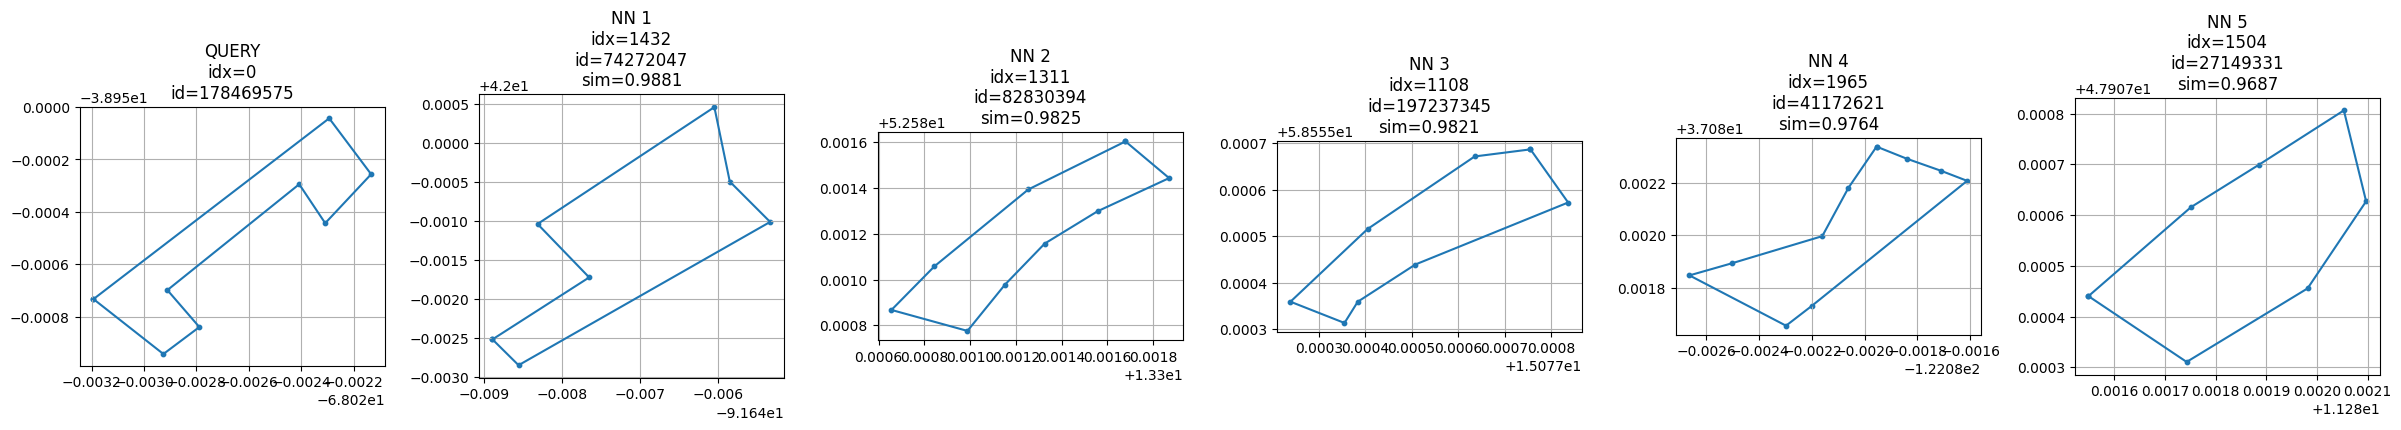

In [16]:
# ============================================================
# CELL 10: Visualize a query polygon and its top neighbors
# ============================================================

import matplotlib.pyplot as plt

def get_ring_by_debug_index(idx):
    return rings_debug[idx]

def plot_ring(ax, ring, title=""):
    ring = np.asarray(ring, dtype=np.float32)

    # close visually if needed
    if not np.allclose(ring[0], ring[-1]):
        ring_plot = np.vstack([ring, ring[0]])
    else:
        ring_plot = ring

    ax.plot(ring_plot[:, 0], ring_plot[:, 1])
    ax.scatter(ring_plot[:, 0], ring_plot[:, 1], s=10)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.grid(True)


QUERY_IDX = 0
TOPK_SHOW = 5

neighbor_indices = top_neighbors[QUERY_IDX][:TOPK_SHOW]

print(f"Query index = {QUERY_IDX}, poly_id = {all_ids[QUERY_IDX]}")
print("Neighbor indices:", neighbor_indices.tolist())

fig, axes = plt.subplots(1, TOPK_SHOW + 1, figsize=(4 * (TOPK_SHOW + 1), 4))

# Query
plot_ring(
    axes[0],
    get_ring_by_debug_index(QUERY_IDX),
    title=f"QUERY\nidx={QUERY_IDX}\nid={all_ids[QUERY_IDX]}"
)

# Neighbors
for j, ni in enumerate(neighbor_indices, start=1):
    plot_ring(
        axes[j],
        get_ring_by_debug_index(ni),
        title=f"NN {j}\nidx={ni}\nid={all_ids[ni]}\nsim={sim[QUERY_IDX, ni]:.4f}"
    )

plt.tight_layout()
plt.show()